In [54]:
import os, random, re
import cv2, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

os.environ['PATH'] = '/opt/homebrew/bin:' + os.environ['PATH']
import pytesseract
pytesseract.pytesseract.tesseract_cmd = '/opt/homebrew/bin/tesseract'
print('pytesseract OK')

SERIAL_PATTERN = re.compile(r'^\d{9}A$')
UPSCALE_FACTOR = 6
random.seed(42)

pytesseract OK


In [55]:
SEGMENTS_DIR = Path('../Data/raw/imagenes_ir/segmentos_ir_billetes')
serie_crops = [p for p in SEGMENTS_DIR.rglob('*.png') if 'serie' in p.parent.name.lower()]
print(f'{len(serie_crops)} crops de serie_a')

2895 crops de serie_a


In [70]:
def deskew(img):
    coords = np.column_stack(np.where(img > 0))
    if len(coords) < 10: return img
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

def preprocess_ocr(img, method='clahe_otsu', upscale=UPSCALE_FACTOR):
    if img is None or img.size == 0: return None
    h, w = img.shape[:2]
    if upscale > 1:
        img = cv2.resize(img, (w*upscale, h*upscale), interpolation=cv2.INTER_CUBIC)
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(5,5))
    img = clahe.apply(img)
    _, result = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Padding blanco para mejorar OCR
    result = cv2.copyMakeBorder(result, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=0)
    if method == 'deskew':
        result = deskew(result)
    return result

def ocr_read(img):
    return pytesseract.image_to_string(img,
        config='--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    ).strip().replace(' ', '').upper()

print('Funciones listas')

Funciones listas


[V] clahe_otsu: "112239722A"
[V] deskew: "112239722A"


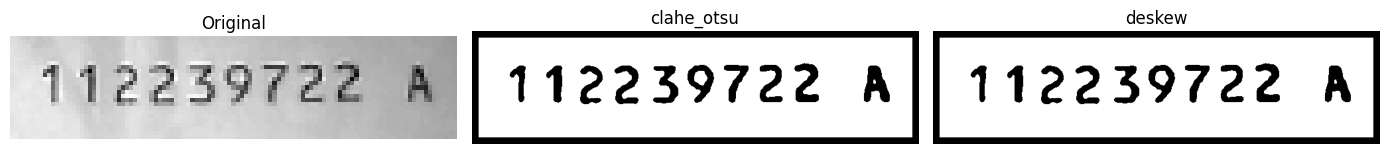

In [71]:
sample = cv2.imread(str(serie_crops[0]), cv2.IMREAD_GRAYSCALE)
for method in ['clahe_otsu', 'deskew']:
    processed = preprocess_ocr(sample, method)
    text = ocr_read(processed)
    ok = 'V' if SERIAL_PATTERN.match(text) else 'X'
    print(f'[{ok}] {method}: "{text}"')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(sample, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
for i, method in enumerate(['clahe_otsu', 'deskew']):
    axes[i+1].imshow(preprocess_ocr(sample, method), cmap='gray')
    axes[i+1].set_title(method); axes[i+1].axis('off')
plt.tight_layout(); plt.show()

In [72]:
from tqdm import tqdm
for method in ['clahe_otsu', 'deskew']:
    valid = 0; total = 0
    for path in tqdm(serie_crops[:200], desc=method):
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        p = preprocess_ocr(img, method)
        if p is None: continue
        total += 1
        if SERIAL_PATTERN.match(ocr_read(p)): valid += 1
    print(f'{method}: {valid}/{total} = {100*valid/total:.1f}%')
print(f'\nUpscale: {UPSCALE_FACTOR}x | Regex: \\d{{9}}A')

clahe_otsu: 100%|██████████| 200/200 [00:14<00:00, 13.95it/s]


clahe_otsu: 190/200 = 95.0%


deskew: 100%|██████████| 200/200 [00:15<00:00, 13.22it/s]

deskew: 190/200 = 95.0%

Upscale: 6x | Regex: \d{9}A
